# 08 — Held-out Perplexity

Quantitative complement to the classifier attribution in `06_evaluation.ipynb`.
For each adapter we measure perplexity on every artist's **held-out** lyrics
(`data/eval.csv`), conditioned on the fixed training prompt (which is masked, so
only the lyric continuation is scored).

The result is a cross-artist matrix. If an adapter genuinely specialized, its
column-minimum lands on the diagonal — i.e. each artist's lyrics are best
predicted (lowest perplexity) by that artist's own adapter, and every adapter
beats the base model on its target artist.

Core logic lives in `perplexity.py` (CPU-tested); this notebook just runs the
forward passes, which need the GPU.

In [ ]:
import pandas as pd

from generation.model import load_base_model
from evaluation.perplexity import perplexity_matrix, plot_perplexity_matrix

base_model, tokenizer = load_base_model()

eval_df = pd.read_csv("./data/eval.csv")
eval_df["artist"].value_counts()

In [ ]:
from config import main_adapters, Adapter

# Rows: base + one headline adapter (LoRA r8) per artist, plus the SW variant.
# Only adapters that exist on disk are included (skip not-yet-trained ones).
specs = main_adapters() + [Adapter("Gojira", "lora", 8, sw=True)]
adapter_map = {"base": None}
for a in specs:
    if a.path.exists():
        key = a.artist.lower() + ("_sw" if a.sw else "")
        adapter_map[key] = str(a.path)

ppl = perplexity_matrix(base_model, tokenizer, adapter_map, eval_df)
ppl.round(1)

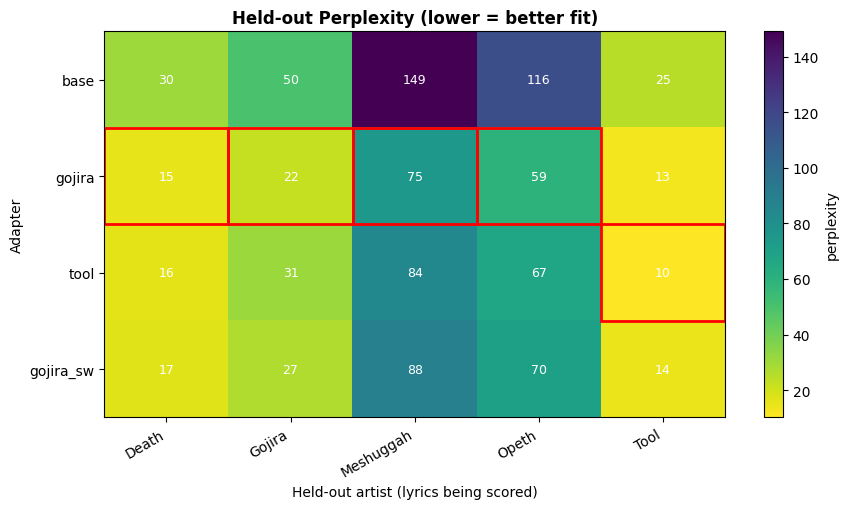

In [3]:
plot_perplexity_matrix(ppl)

## Reading the matrix

- **Lower = better fit.** Red boxes mark the per-column minimum.
- **Specialization:** each adapter's perplexity on its own artist should be the
  lowest in that column, and below the `base` row.
- **Cross-talk:** Gojira and Tool sit close in style, so off-diagonal cells will
  not be huge — the relevant signal is the *ordering* (own-artist lowest), not
  the absolute gap.
- Pairs with the attribution numbers in `06_evaluation.ipynb`: attribution says
  "the output reads like artist X"; perplexity says "the adapter assigns higher
  likelihood to artist X's real lyrics". Two independent angles on the same claim.